<a href="https://colab.research.google.com/github/Aswin-2002/Synthetic-Brain-MRI-Generation-using-Diffusion-model-DDPM-for-alzheimer/blob/main/ddpmcoronal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Safe remount — always run this first
import os, shutil, subprocess
from google.colab import drive

subprocess.run(['fusermount', '-uz', '/content/drive'], capture_output=True)
shutil.rmtree('/content/drive', ignore_errors=True)
os.makedirs('/content/drive', exist_ok=True)

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install diffusers accelerate torchvision -q

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Update this path to your coronal alzheimers folder
DATA_DIR = '/content/drive/MyDrive/oasis-coronal-alzheimers'

files = [f for f in os.listdir(DATA_DIR) if f.endswith('.png')]
print(f"Found {len(files)} images")
print(f"Sample: {files[:3]}")

ValueError: Mountpoint must not already contain files

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB
Loaded 700 images
Steps per epoch : 88
Total steps     : 4400

Loading pretrained brain MRI DDPM...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

Model parameters: 113,668,609

Starting training...



/tmp/ipykernel_2126/1250962358.py:81: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()  # mixed precision
/tmp/ipykernel_2126/1250962358.py:98: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 001/50 | Loss: 0.039269
Epoch 002/50 | Loss: 0.030435
Epoch 003/50 | Loss: 0.030903
Epoch 004/50 | Loss: 0.027406
Epoch 005/50 | Loss: 0.026920
Epoch 006/50 | Loss: 0.027388
Epoch 007/50 | Loss: 0.027030
Epoch 008/50 | Loss: 0.024482
Epoch 009/50 | Loss: 0.024332
Epoch 010/50 | Loss: 0.024760
  ✅ Checkpoint saved → /content/drive/MyDrive/ddpm_coronal_checkpoints/epoch_010


/tmp/ipykernel_2126/1250962358.py:129: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


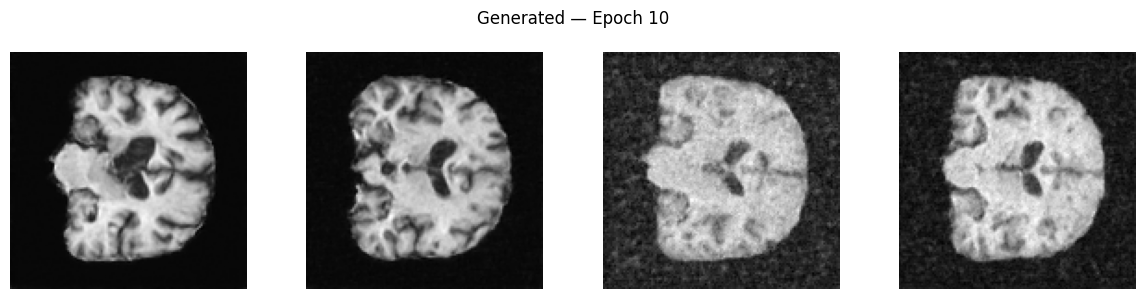

Epoch 011/50 | Loss: 0.021782
Epoch 012/50 | Loss: 0.023628
Epoch 013/50 | Loss: 0.020385
Epoch 014/50 | Loss: 0.029259
Epoch 015/50 | Loss: 0.022871
Epoch 016/50 | Loss: 0.022313
Epoch 017/50 | Loss: 0.023054
Epoch 018/50 | Loss: 0.021209
Epoch 019/50 | Loss: 0.025014
Epoch 020/50 | Loss: 0.021996
  ✅ Checkpoint saved → /content/drive/MyDrive/ddpm_coronal_checkpoints/epoch_020


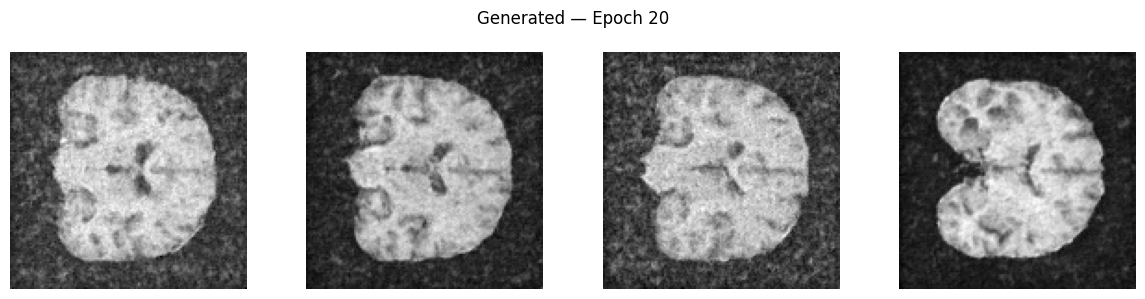

Epoch 021/50 | Loss: 0.019197
Epoch 022/50 | Loss: 0.022395
Epoch 023/50 | Loss: 0.019536
Epoch 024/50 | Loss: 0.021036
Epoch 025/50 | Loss: 0.020998
Epoch 026/50 | Loss: 0.019354
Epoch 027/50 | Loss: 0.022450
Epoch 028/50 | Loss: 0.022236
Epoch 029/50 | Loss: 0.019819
Epoch 030/50 | Loss: 0.015978
  ✅ Checkpoint saved → /content/drive/MyDrive/ddpm_coronal_checkpoints/epoch_030


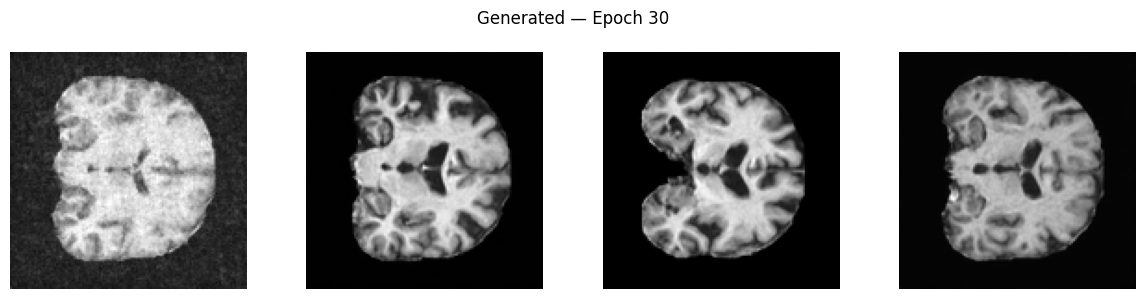

Epoch 031/50 | Loss: 0.020944
Epoch 032/50 | Loss: 0.021301
Epoch 033/50 | Loss: 0.019224
Epoch 034/50 | Loss: 0.021854
Epoch 035/50 | Loss: 0.017638
Epoch 036/50 | Loss: 0.020238
Epoch 037/50 | Loss: 0.018247
Epoch 038/50 | Loss: 0.019923
Epoch 039/50 | Loss: 0.016522
Epoch 040/50 | Loss: 0.019509
  ✅ Checkpoint saved → /content/drive/MyDrive/ddpm_coronal_checkpoints/epoch_040


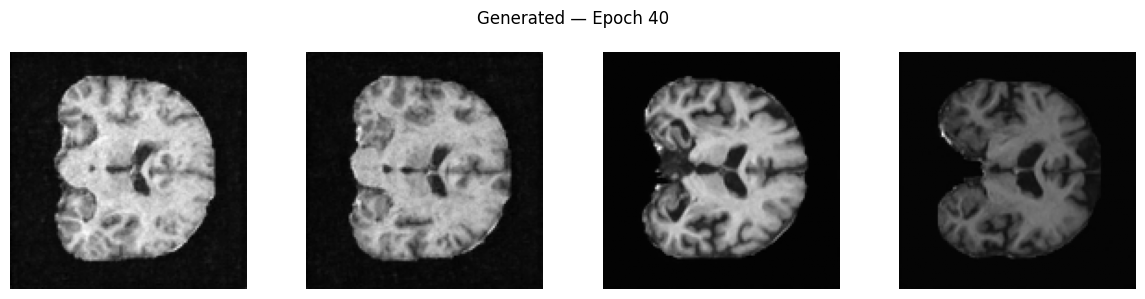

Epoch 041/50 | Loss: 0.017889
Epoch 042/50 | Loss: 0.017955
Epoch 043/50 | Loss: 0.016150
Epoch 044/50 | Loss: 0.019699
Epoch 045/50 | Loss: 0.018324
Epoch 046/50 | Loss: 0.020121
Epoch 047/50 | Loss: 0.018626
Epoch 048/50 | Loss: 0.020502
Epoch 049/50 | Loss: 0.018102
Epoch 050/50 | Loss: 0.016938
  ✅ Checkpoint saved → /content/drive/MyDrive/ddpm_coronal_checkpoints/epoch_050


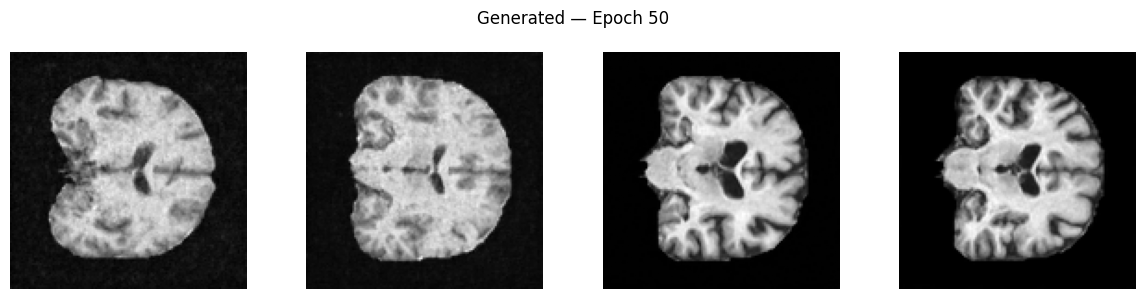


✅ Done! Final model saved to Google Drive


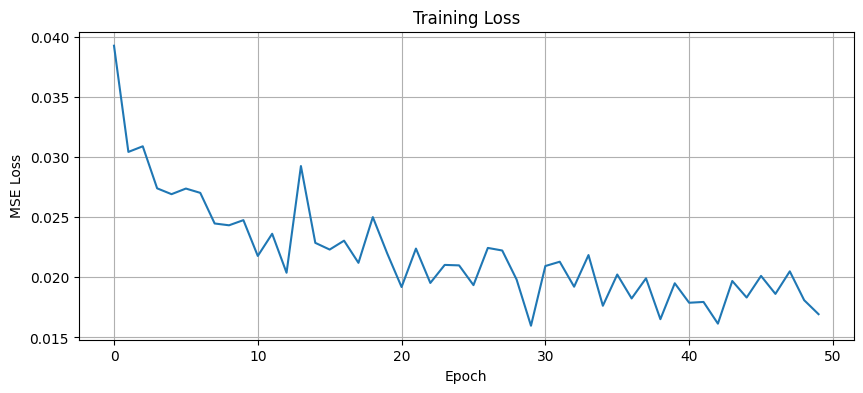

In [ ]:
import os
import torch
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from diffusers import DDPMPipeline, DDPMScheduler
from diffusers.optimization import get_cosine_schedule_with_warmup
from torchvision import transforms
import matplotlib.pyplot as plt

# ── Config ───────────────────────────────────────────────
DATA_DIR       = '/content/drive/MyDrive/oasis-coronal-alzheimers'
OUTPUT_DIR     = '/content/drive/MyDrive/ddpm_coronal_output'
CHECKPOINT_DIR = '/content/drive/MyDrive/ddpm_coronal_checkpoints'

IMAGE_SIZE    = 128
BATCH_SIZE    = 8
NUM_EPOCHS    = 50
LEARNING_RATE = 1e-4
SAVE_EVERY    = 10
NUM_TIMESTEPS = 1000

os.makedirs(OUTPUT_DIR,     exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
print(f"GPU    : {torch.cuda.get_device_name(0)}")
print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ── Dataset ──────────────────────────────────────────────
class MRIDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir   = img_dir
        self.files     = [f for f in os.listdir(img_dir) if f.endswith('.png')]
        self.transform = transform
        print(f"Loaded {len(self.files)} images")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img  = Image.open(os.path.join(self.img_dir, self.files[idx])).convert('L')
        if self.transform:
            img = self.transform(img)
        return img

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

dataset    = MRIDataset(DATA_DIR, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE,
                        shuffle=True, num_workers=2)

steps_per_epoch = len(dataloader)
total_steps     = steps_per_epoch * NUM_EPOCHS
print(f"Steps per epoch : {steps_per_epoch}")
print(f"Total steps     : {total_steps}")

# ── Load pretrained model ────────────────────────────────
print("\nLoading pretrained brain MRI DDPM...")
pipeline  = DDPMPipeline.from_pretrained("benetraco/brain_ddpm_128")
model     = pipeline.unet.to(device)
scheduler = DDPMScheduler(
    num_train_timesteps=NUM_TIMESTEPS,
    beta_schedule="squaredcos_cap_v2"
)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# ── Optimizer ────────────────────────────────────────────
optimizer    = torch.optim.AdamW(model.parameters(),
                                  lr=LEARNING_RATE, weight_decay=1e-4)
lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=100,
    num_training_steps=total_steps,
)
scaler = torch.cuda.amp.GradScaler()  # mixed precision

# ── Training loop ────────────────────────────────────────
print("\nStarting training...\n")
loss_history = []

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0

    for batch in dataloader:
        images    = batch.to(device)
        timesteps = torch.randint(0, NUM_TIMESTEPS,
                                  (images.shape[0],), device=device).long()
        noise     = torch.randn_like(images)
        noisy     = scheduler.add_noise(images, noise, timesteps)

        with torch.cuda.amp.autocast():
            pred = model(noisy, timesteps).sample
            loss = torch.nn.functional.mse_loss(pred, noise)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        lr_scheduler.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(dataloader)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1:03d}/{NUM_EPOCHS} | Loss: {avg_loss:.6f}")

    # Save checkpoint
    if (epoch + 1) % SAVE_EVERY == 0:
        ckpt_path = os.path.join(CHECKPOINT_DIR, f'epoch_{epoch+1:03d}')
        pipeline.unet = model
        pipeline.save_pretrained(ckpt_path)
        print(f"  ✅ Checkpoint saved → {ckpt_path}")

    # Generate and show sample images
    if (epoch + 1) % 10 == 0:
        model.eval()
        with torch.no_grad():
            sample = torch.randn(4, 1, IMAGE_SIZE, IMAGE_SIZE).to(device)
            for t in scheduler.timesteps:
                with torch.cuda.amp.autocast():
                    pred   = model(sample, t).sample
                sample = scheduler.step(pred, t, sample).prev_sample

            sample = (sample.clamp(-1, 1) + 1) / 2
            fig, axes = plt.subplots(1, 4, figsize=(12, 3))
            fig.suptitle(f'Generated — Epoch {epoch+1}')
            for i in range(4):
                axes[i].imshow(sample[i, 0].cpu().numpy(), cmap='gray')
                axes[i].axis('off')
            plt.tight_layout()
            plt.savefig(f'{OUTPUT_DIR}/samples_epoch_{epoch+1:03d}.png')
            plt.show()

# ── Save final model ─────────────────────────────────────
pipeline.unet = model
pipeline.save_pretrained(f'{OUTPUT_DIR}/final_model')
print("\n✅ Done! Final model saved to Google Drive")

# ── Loss curve ───────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(loss_history)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True)
plt.savefig(f'{OUTPUT_DIR}/loss_curve.png')
plt.show()

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

Generating synthetic Alzheimer's coronal MRI slices...


  0%|          | 0/1000 [00:00<?, ?it/s]

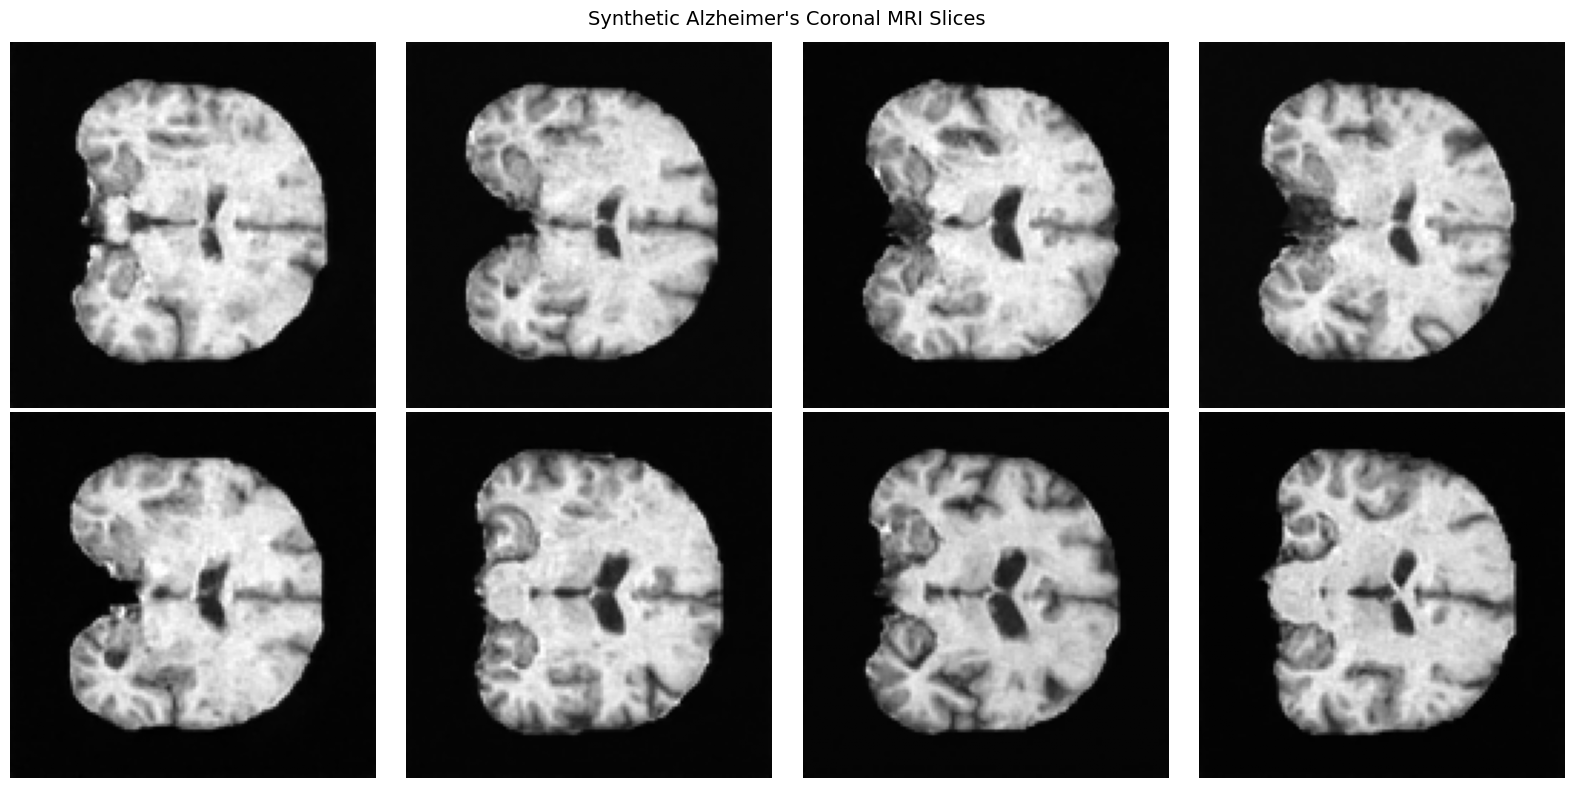

In [ ]:
# Generating synthetic images

import torch
import matplotlib.pyplot as plt
from diffusers import DDPMPipeline, DDPMScheduler

# Load your fine-tuned model
MODEL_PATH = '/content/drive/MyDrive/ddpm_coronal_output/final_model'

pipeline = DDPMPipeline.from_pretrained(MODEL_PATH).to('cuda')

# Generate 8 synthetic images
print("Generating synthetic Alzheimer's coronal MRI slices...")
with torch.no_grad():
    images = pipeline(batch_size=8, num_inference_steps=1000).images

# Display them
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Synthetic Alzheimer\'s Coronal MRI Slices', fontsize=14)
for i, img in enumerate(images):
    row, col = i // 4, i % 4
    axes[row, col].imshow(img, cmap='gray')
    axes[row, col].axis('off')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ddpm_coronal_output/final_samples.png')
plt.show()

In [ ]:
# Checking for correlation (real vs synthetic images)

import numpy as np
from PIL import Image
import os

# Load a sample of real training images for comparison
real_dir = '/content/drive/MyDrive/oasis-coronal-alzheimers'
real_files = [f for f in os.listdir(real_dir) if f.endswith('.png')][:50]

real_images = []
for f in real_files:
    img = Image.open(os.path.join(real_dir, f)).convert('L').resize((128,128))
    real_images.append(np.array(img).flatten())
real_images = np.array(real_images)

# Compare each generated image to all real images using correlation
def max_correlation(gen_img, real_imgs):
    gen_flat = np.array(gen_img.convert('L').resize((128,128))).flatten()
    correlations = [np.corrcoef(gen_flat, r)[0,1] for r in real_imgs]
    return max(correlations)

print("Checking memorisation (correlation with real training data)...")
for i, img in enumerate(images):  # 'images' from your generation step
    max_corr = max_correlation(img, real_images)
    print(f"Sample {i+1}: max correlation = {max_corr:.3f}")

Checking memorisation (correlation with real training data)...
Sample 1: max correlation = 0.937
Sample 2: max correlation = 0.946
Sample 3: max correlation = 0.936
Sample 4: max correlation = 0.934
Sample 5: max correlation = 0.939
Sample 6: max correlation = 0.935
Sample 7: max correlation = 0.933
Sample 8: max correlation = 0.938


Too much correlation with the real data. Too similar with little variation. Acceptable range: 0.70-.80

In [ ]:
# checking correlation for all checkpoints at 10.20,30,40
import torch
from diffusers import DDPMPipeline
import numpy as np
from PIL import Image
import os

real_dir = '/content/drive/MyDrive/oasis-coronal-alzheimers'
real_files = [f for f in os.listdir(real_dir) if f.endswith('.png')][:50]
real_images = []
for f in real_files:
    img = Image.open(os.path.join(real_dir, f)).convert('L').resize((128,128))
    real_images.append(np.array(img).flatten())
real_images = np.array(real_images)

def max_correlation(gen_img, real_imgs):
    gen_flat = np.array(gen_img.convert('L').resize((128,128))).flatten()
    correlations = [np.corrcoef(gen_flat, r)[0,1] for r in real_imgs]
    return max(correlations)

# Check each saved checkpoint
checkpoint_dir = '/content/drive/MyDrive/ddpm_coronal_checkpoints'
for ckpt_name in sorted(os.listdir(checkpoint_dir)):
    ckpt_path = os.path.join(checkpoint_dir, ckpt_name)
    pipeline = DDPMPipeline.from_pretrained(ckpt_path).to('cuda')

    with torch.no_grad():
        images = pipeline(batch_size=4, num_inference_steps=1000).images

    corrs = [max_correlation(img, real_images) for img in images]
    print(f"{ckpt_name}: avg max correlation = {np.mean(corrs):.3f}")

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

epoch_010: avg max correlation = 0.922


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

epoch_040: avg max correlation = 0.931


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

epoch_050: avg max correlation = 0.942


In [ ]:
# real vs real correlation

import numpy as np
from PIL import Image
import os

real_dir = '/content/drive/MyDrive/oasis-coronal-alzheimers'
real_files = [f for f in os.listdir(real_dir) if f.endswith('.png')][:60]

real_images = []
for f in real_files:
    img = Image.open(os.path.join(real_dir, f)).convert('L').resize((128,128))
    real_images.append(np.array(img).flatten())
real_images = np.array(real_images)

# For each real image, find its max correlation with OTHER real images
# (excluding itself) — this is the natural "baseline" similarity
intra_real_corrs = []
for i in range(len(real_images)):
    others = np.delete(real_images, i, axis=0)
    corrs  = [np.corrcoef(real_images[i], r)[0,1] for r in others]
    intra_real_corrs.append(max(corrs))

print(f"Real-vs-Real baseline correlation:")
print(f"  Mean: {np.mean(intra_real_corrs):.3f}")
print(f"  Min:  {np.min(intra_real_corrs):.3f}")
print(f"  Max:  {np.max(intra_real_corrs):.3f}")

Real-vs-Real baseline correlation:
  Mean: 0.937
  Min:  0.907
  Max:  0.956


No problem with current model. Real images are also similar to each other. New finding!

In [ ]:
# FID Score

!pip install torch-fidelity -q

import torch
from torch_fidelity import calculate_metrics
import os

# Save generated images temporarily for FID calculation
GEN_DIR  = '/content/drive/MyDrive/ddpm_coronal_output/fid_generated'
REAL_DIR = '/content/drive/MyDrive/oasis-coronal-alzheimers'

os.makedirs(GEN_DIR, exist_ok=True)

# Generate 100 images for a more reliable FID estimate
print("Generating 100 synthetic images for FID calculation...")
from diffusers import DDPMPipeline

MODEL_PATH = '/content/drive/MyDrive/ddpm_coronal_output/final_model'
pipeline = DDPMPipeline.from_pretrained(MODEL_PATH).to('cuda')

count = 0
while count < 100:
    batch_size = min(8, 100 - count)
    with torch.no_grad():
        images = pipeline(batch_size=batch_size, num_inference_steps=1000).images
    for img in images:
        img.convert('RGB').save(f'{GEN_DIR}/gen_{count:03d}.png')
        count += 1
    print(f"Generated {count}/100")

print("\nCalculating FID...")
metrics = calculate_metrics(
    input1=GEN_DIR,
    input2=REAL_DIR,
    cuda=True,
    fid=True,
    verbose=False
)
print(f"\nFID Score: {metrics['frechet_inception_distance']:.2f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 9.4 MB/s eta 0:00:00
Generating 100 synthetic images for FID calculation...


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Generated 8/100


  0%|          | 0/1000 [00:00<?, ?it/s]

...

Generated 96/100


  0%|          | 0/1000 [00:00<?, ?it/s]

Generated 100/100

Calculating FID...


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation mig


FID Score: 126.97


In [ ]:
import os
import random
import shutil
from torch_fidelity import calculate_metrics

REAL_DIR = '/content/drive/MyDrive/oasis-coronal-alzheimers'
SPLIT_A  = '/content/drive/MyDrive/ddpm_coronal_output/real_split_a'
SPLIT_B  = '/content/drive/MyDrive/ddpm_coronal_output/real_split_b'

os.makedirs(SPLIT_A, exist_ok=True)
os.makedirs(SPLIT_B, exist_ok=True)

all_files = [f for f in os.listdir(REAL_DIR) if f.endswith('.png')]
random.shuffle(all_files)

half = len(all_files) // 2
files_a = all_files[:half]
files_b = all_files[half:half*2]

for f in files_a:
    shutil.copy(os.path.join(REAL_DIR, f), os.path.join(SPLIT_A, f))
for f in files_b:
    shutil.copy(os.path.join(REAL_DIR, f), os.path.join(SPLIT_B, f))

print(f"Split A: {len(files_a)} images")
print(f"Split B: {len(files_b)} images")

print("\nCalculating Real-vs-Real baseline FID...")
metrics = calculate_metrics(
    input1=SPLIT_A,
    input2=SPLIT_B,
    cuda=True,
    fid=True,
    verbose=False
)
print(f"\nReal-vs-Real Baseline FID: {metrics['frechet_inception_distance']:.2f}")

Split A: 350 images
Split B: 350 images

Calculating Real-vs-Real baseline FID...

Real-vs-Real Baseline FID: 18.74


In [ ]:
#generate more images than before

import torch
from diffusers import DDPMPipeline
import os

GEN_DIR = '/content/drive/MyDrive/ddpm_coronal_output/fid_generated_350'
os.makedirs(GEN_DIR, exist_ok=True)

MODEL_PATH = '/content/drive/MyDrive/ddpm_coronal_output/final_model'
pipeline = DDPMPipeline.from_pretrained(MODEL_PATH).to('cuda')

print("Generating 350 synthetic images to match real sample size...")
count = 0
while count < 350:
    batch_size = min(8, 350 - count)
    with torch.no_grad():
        images = pipeline(batch_size=batch_size, num_inference_steps=1000).images
    for img in images:
        img.convert('RGB').save(f'{GEN_DIR}/gen_{count:03d}.png')
        count += 1
    if count % 50 == 0:
        print(f"Generated {count}/350")

print("Done generating.")

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

Generating 350 synthetic images to match real sample size...


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

In [ ]:
!pip install torch-fidelity -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 3.3 MB/s eta 0:00:00


In [ ]:
# Just create a 100-image real split to match your existing 100 generated images
import os
import random
import shutil
from torch_fidelity import calculate_metrics

# ── Step 1: Mount drive (skip if already mounted) ───────
#from google.colab import drive
#drive.mount('/content/drive')

# ── Step 2: Paths ─────────────────────────────────────────
REAL_DIR        = '/content/drive/MyDrive/oasis-coronal-alzheimers'
GEN_DIR         = '/content/drive/MyDrive/ddpm_coronal_output/fid_generated'  # your existing 100 images
REAL_SPLIT_100  = '/content/drive/MyDrive/ddpm_coronal_output/real_split_100'

os.makedirs(REAL_SPLIT_100, exist_ok=True)

# ── Step 3: Verify generated images exist ────────────────
gen_files = [f for f in os.listdir(GEN_DIR) if f.endswith('.png')]
print(f"Found {len(gen_files)} generated images in {GEN_DIR}")

# ── Step 4: Create matching 100-image real split ─────────
all_real_files = [f for f in os.listdir(REAL_DIR) if f.endswith('.png')]
random.seed(42)  # reproducible split
random.shuffle(all_real_files)

selected_real = all_real_files[:100]
for f in selected_real:
    shutil.copy(
        os.path.join(REAL_DIR, f),
        os.path.join(REAL_SPLIT_100, f)
    )

print(f"Created real split with {len(os.listdir(REAL_SPLIT_100))} images")

# ── Step 5: Calculate FID (100 generated vs 100 real) ─────
print("\nCalculating FID (100 vs 100, fair comparison)...")
metrics = calculate_metrics(
    input1=GEN_DIR,
    input2=REAL_SPLIT_100,
    cuda=True,
    fid=True,
    verbose=False
)

print(f"\n{'='*45}")
print(f"FID Score (100 generated vs 100 real): {metrics['frechet_inception_distance']:.2f}")
print(f"{'='*45}")

Found 100 generated images in /content/drive/MyDrive/ddpm_coronal_output/fid_generated
Created real split with 100 images

Calculating FID (100 vs 100, fair comparison)...


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation mig


FID Score (100 generated vs 100 real): 136.22


In [ ]:
from diffusers import DDIMPipeline, DDIMScheduler
import torch
import os

MODEL_PATH = '/content/drive/MyDrive/ddpm_coronal_output/final_model'
GEN_DIR    = '/content/drive/MyDrive/ddpm_coronal_output/fid_generated_350'
os.makedirs(GEN_DIR, exist_ok=True)

# Load same trained model, but with DDIM scheduler for fast sampling
pipeline = DDIMPipeline.from_pretrained(MODEL_PATH).to('cuda')

print("Generating 350 images using fast DDIM sampling (50 steps)...")
count = 0
while count < 350:
    batch_size = min(16, 350 - count)  # larger batch since each step is cheaper
    with torch.no_grad():
        images = pipeline(
            batch_size=batch_size,
            num_inference_steps=50   # ← key change: 50 instead of 1000
        ).images
    for img in images:
        img.convert('RGB').save(f'{GEN_DIR}/gen_{count:03d}.png')
        count += 1
    print(f"Generated {count}/350")

print("✅ Done generating!")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

Generating 350 images using fast DDIM sampling (50 steps)...


  0%|          | 0/50 [00:00<?, ?it/s]

Generated 16/350


...

Generated 320/350


  0%|          | 0/50 [00:00<?, ?it/s]

Generated 336/350


  0%|          | 0/50 [00:00<?, ?it/s]

Generated 350/350
✅ Done generating!


In [ ]:
# USING DDIM for experimentation
from torch_fidelity import calculate_metrics
import os

# ── Paths ──────────────────────────────────────────────
GEN_DIR_350  = '/content/drive/MyDrive/ddpm_coronal_output/fid_generated_350'  # your DDIM images
REAL_SPLIT_A = '/content/drive/MyDrive/ddpm_coronal_output/real_split_a'        # 350 real images from earlier

# ── Verify both folders have matching counts ──────────
gen_count  = len([f for f in os.listdir(GEN_DIR_350) if f.endswith('.png')])
real_count = len([f for f in os.listdir(REAL_SPLIT_A) if f.endswith('.png')])
print(f"Generated images: {gen_count}")
print(f"Real images:      {real_count}")

# ── Calculate FID ──────────────────────────────────────
print("\nCalculating FID (350 DDIM-generated vs 350 real)...")
metrics = calculate_metrics(
    input1=GEN_DIR_350,
    input2=REAL_SPLIT_A,
    cuda=True,
    fid=True,
    verbose=False
)

print(f"\n{'='*45}")
print(f"FID Score (350 vs 350): {metrics['frechet_inception_distance']:.2f}")
print(f"{'='*45}")

Generated images: 350
Real images:      350

Calculating FID (350 DDIM-generated vs 350 real)...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



FID Score (350 vs 350): 91.03


In [ ]:
#GENERATING 350 total DDPM syntheic images for later classification

import torch
from diffusers import DDPMPipeline
import os

GEN_DIR = '/content/drive/MyDrive/ddpm_coronal_output/fid_generated'  # adds to existing 100
MODEL_PATH = '/content/drive/MyDrive/ddpm_coronal_output/final_model'

pipeline = DDPMPipeline.from_pretrained(MODEL_PATH).to('cuda')

existing = len([f for f in os.listdir(GEN_DIR) if f.endswith('.png')])
target   = 350  # aim for 300 total DDPM images
print(f"Already have {existing}, generating up to {target}...")

count = existing
while count < target:
    batch_size = min(8, target - count)
    with torch.no_grad():
        images = pipeline(batch_size=batch_size, num_inference_steps=1000).images
    for img in images:
        img.convert('RGB').save(f'{GEN_DIR}/gen_{count:03d}.png')
        count += 1
    print(f"Generated {count}/{target}")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

Already have 204, generating up to 350...


  0%|          | 0/1000 [00:00<?, ?it/s]

Generated 212/350


...

Generated 340/350


  0%|          | 0/1000 [00:00<?, ?it/s]

Generated 348/350


  0%|          | 0/1000 [00:00<?, ?it/s]

Generated 350/350
